# Theta-e extra plots: w

In [4]:
import numpy as np
import xarray as xr
import pandas as pd
import sys
import os
from datetime import datetime

from pathlib import Path
import glob
import logging
import dask
import calendar
import iris
from scipy import special
from scipy.interpolate import griddata
from scipy.interpolate import RegularGridInterpolator
import scipy.special
from scipy.stats import mannwhitneyu
from scipy.stats import gaussian_kde
from math import sin, cos, sqrt, atan2, radians, asin
from typing import TypedDict, Optional
import functools

#plotting libraries
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, TwoSlopeNorm, BoundaryNorm, Normalize
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import matplotlib.path as mpath
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature

# import functions
sys.path.append(os.path.join(r"/home/563/ac9768/PhD")) 
sys.path.append(os.path.join(r"/home/563/ac9768/PhD/Plotting_scripts")) 
from Plotting_scripts import get_subplot_axes, plot_data_on_axes, plot_violins_seasons, plot_violins_regions
from Plotting_scripts import latitude_weighting, time_weighting
from Plotting_scripts import plot_polar_ndjf_plots, plot_polar_single
from Plotting_scripts import monthly_flux_to_TgS
from Plotting_scripts import get_grid_size

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2    
# %reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
from dask_setup import setup_dask_client 
from dask_setup import recommend_chunks
client, cluster, dask_tmp = setup_dask_client(mode="interactive", workload_type="auto")
warnings.simplefilter(action='ignore', category=FutureWarning)

INFO     [client] Interactive cluster mode — using already-allocated nodes
INFO     [multinode] Interactive cluster: single node, using LocalCluster (node=gadi-cpu-bdw-0621.gadi.nci.org.au)
INFO     [client] Starting Dask client setup (workload_type=auto | environment=jupyter)
INFO     [resources] Resources detected via PBS (total_cores=28 | total_mem_gib=252.0)
INFO     [client] workload_type='auto' resolved via dataset inspection (workload_type=mixed)


INFO     [client] Temp/spill dir: /jobfs/169705756.gadi-pbs/dask-2211332
INFO     [client] Workers: 14 | threads/worker: 2 | processes: True
INFO     [client] Mem: total ~252.0 GiB | usable ~202.0 GiB | per-worker ~14.4 GiB
INFO     [client] Compression: spill=auto | comm=False
INFO     [client] Dask client ready


[setup_dask_client] Configuration summary
temp/spill dir: /jobfs/169705756.gadi-pbs/dask-2211332
Workers: 14 | threads/worker: 2 | processes: True
Memory: total ~252.0 GiB | usable ~202.0 GiB | per-worker ~14.4 GiB
Compression: spill=auto | comm=False


# Open BARRA-R2 dataset

In [3]:
def list_barra_paths(var: str):
    """Create list of file paths for the BARRA-R2 variable.
    Using a base path, once the variable is chosen all file paths within the years and months are returned as a list.

    Args:
        var (str): String of radar ID number; towns = 73, cairns = "19", willis island = "41"
        temp_dir (str): Directory to store .nc files, default = "/scratch/v46/ac9768/radar_grndref/"
    Returns:
        list: List of extracted .nc file path strings
    """
    base = "/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/1hr/"+var+"/latest/"
    # analysis years
    year = np.arange(1979,2025,1)
    # analysis months
    month = ['01','02','03','04']
    list = sorted(
        f
        for y in year
        for m in month
        for f in glob.glob(base+var+f"_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_1hr_{y}{m}-{y}{m}.nc")
    )

    if not list:
        raise FileNotFoundError("No files found — check the path.")
        
    list.sort()
    return list

In [4]:
Ps = [1000, 925, 850, 700, 600, 500, 400, 300, 200] #hPa
wa_fps = []
for P in Ps:
    wa_fps.extend(list_barra_paths('wa'+str(P)))

In [5]:
def preprocess(ds):
    ds = ds.sel(lat=slice(-17, -16.6), lon=slice(143, 152))
    
    # Extract all wa variables and combine along pressure dimension
    wa_vars = {var: ds[var] for var in ds.data_vars if var.startswith('wa')}
    
    if wa_vars:
        # Extract pressure levels from variable names (e.g., 'wa1000' -> 1000)
        pressure_levels = []
        wa_data_arrays = []
        
        for var in sorted(wa_vars.keys()):
            # Extract pressure from variable name
            pressure = int(var.replace('wa', ''))
            pressure_levels.append(pressure)
            wa_data_arrays.append(wa_vars[var])
        
        # Combine into single DataArray with pressure dimension
        wa_combined = xr.concat(wa_data_arrays, dim='pressure')
        wa_combined['pressure'] = pressure_levels
        
        # Create new dataset with just the combined 'wa' variable
        ds = ds.drop_vars(list(wa_vars.keys()))
        ds['wa'] = wa_combined
    
    return ds

In [6]:
wa = xr.open_mfdataset(wa_fps,preprocess=preprocess,engine='h5netcdf',parallel=True)

# Define wind regimes 2012-2022

In [7]:
barra_cairns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_cairns.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1979-01-01T00:00:00.000000000','2024-05-01T00:00:00.000000000'))

In [8]:
def utc_to_lst_shift(ds, longitude_center: float):
    """
    Shift xarray data from UTC to Local Solar Time by offsetting the 
    time coordinate. Adds the LST offset to time labels directly —
    does NOT roll/wrap data values.

    Args:
        ds:               xarray Dataset or DataArray with a 'time' dimension.
        longitude_center: Representative longitude of the region (decimal degrees).

    Returns:
        Dataset/DataArray with time coordinate relabelled to LST.
    """
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    ds_lst = ds.assign_coords(time=ds.time + offset)
    return ds_lst

In [9]:
def wind_times(barra_regime_ds: xr.Dataset, longitude_center: float):
    """
    Classify wind direction at LST solar noon (hour=12), then assign
    all hours of that day to the same wind regime.

    Args:
        barra_regime_ds:  xarray Dataset with 'wind_dir' and 'time' dimension.
        longitude_center: Representative longitude for LST conversion.

    Returns:
        ne, se, sw, nw: arrays of datetime64 timestamps (all hours) 
                        belonging to each wind regime day.
    """
    # 1. Shift full dataset to LST
    ds_lst = utc_to_lst_shift(barra_regime_ds, longitude_center)

    # 2. Extract wind_dir and compute (needed for boolean indexing)
    winds = ds_lst.wind_dir.compute()

    # 3. Select only solar noon (LST hour=12) for regime classification
    winds_noon = winds.sel(time=winds.time.dt.hour == 12)

    # 4. Classify noon wind direction → get dates (not full timestamps)
    ne_dates = winds_noon.time.values[(winds_noon.values >= 0)   & (winds_noon.values <= 90)]
    se_dates = winds_noon.time.values[(winds_noon.values > 90)   & (winds_noon.values <= 180)]
    sw_dates = winds_noon.time.values[(winds_noon.values > 180)  & (winds_noon.values <= 270)]
    nw_dates = winds_noon.time.values[(winds_noon.values > 270)  & (winds_noon.values <= 360)]

    # 5. Convert noon timestamps → date-only for day matching
    def noon_to_all_hours(regime_noon_times):
        """Given noon timestamps, return all LST timestamps on those days."""
        regime_dates = set(
            pd.Timestamp(t).date() for t in regime_noon_times
        )
        all_times = pd.DatetimeIndex(winds.time.values)
        mask = all_times.normalize().map(lambda d: d.date() in regime_dates)
        return winds.time.values[mask]

    ne_lst = noon_to_all_hours(ne_dates)
    se_lst = noon_to_all_hours(se_dates)
    sw_lst = noon_to_all_hours(sw_dates)
    nw_lst = noon_to_all_hours(nw_dates)

    # 6. Convert LST timestamps back to UTC by subtracting the offset
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    # ds_lst = ds.assign_coords(time=ds.time + offset)

    
    # offset_hours = round(longitude_center * 4 / 60)
    # offset = np.timedelta64(offset_hours, 'h')

    ne = ne_lst - offset
    se = se_lst - offset
    sw = sw_lst - offset
    nw = nw_lst - offset

    return ne, se, sw, nw


# --- Usage ---
lon_towns  = (145.12054 + 147.9812)  / 2  # ≈ 146.55°E
lon_cairns = (144.27374 + 147.09222) / 2  # ≈ 145.68°E
lon_willis = (148.55927 + 151.36993) / 2

In [10]:
ne_cairns, se_cairns, sw_cairns, nw_cairns = wind_times(barra_cairns, lon_cairns)

# Compute variable under wind regimes

In [11]:
regimes = {'ne': ne_cairns, 
           'se': se_cairns,
           'sw': sw_cairns,
           'nw': nw_cairns,
          }
results = {}
for regime, times in regimes.items():
    results[regime] = wa.sel(time=times).mean(['lat','time'])

In [ ]:
# # Save results to NetCDF files
# for regime in ['nw', 'ne', 'sw', 'se']:
#     results[regime].to_netcdf(f'/home/563/ac9768/GBR/scripts/Paper_figures/theta-e_extras/wa_{regime}_regime_cairns_1979-2024.nc')

# results['se'].to_netcdf(f'/home/563/ac9768/GBR/scripts/Paper_figures/theta-e_extras/wa_se_regime_cairns_1979-2024.nc')

# Plot

(143.0, 152.0)

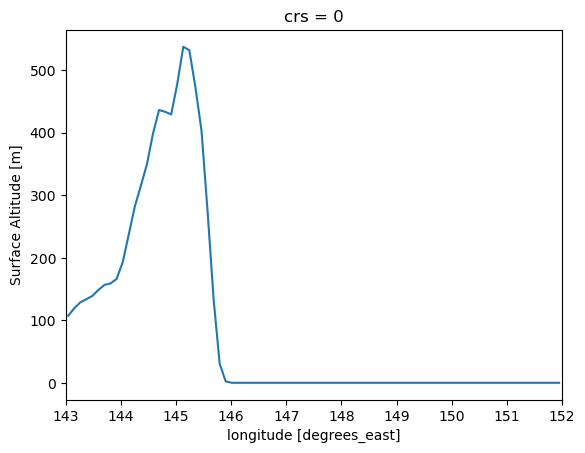

In [77]:
barra_orog = "/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/fx/orog/latest/orog_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1.nc"
ds_orog = xr.open_dataset(barra_orog).sel(lat=slice(-17, -16.6),lon=slice(143,152)).mean(dim='lat')
# ds_orog = ds_orog.where(ds_orog.orog>0)
ds_orog.orog.plot()
plt.xlim(143,152)

(143.0, 152.0)

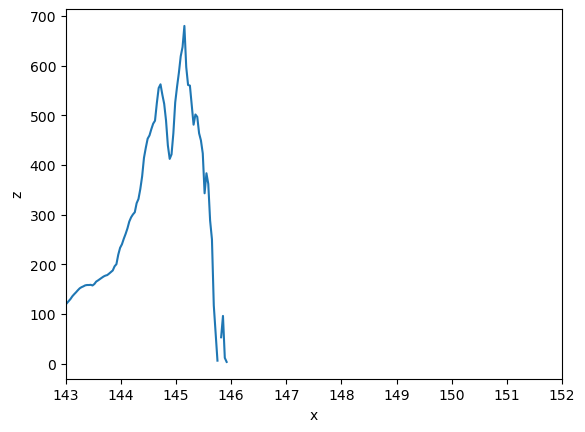

In [55]:
ds_full = xr.open_dataset('/home/563/ac9768/GBR/Aus_Bathymetry/ETOPO2v2c_f4.GQp62nWv.nc.part', engine="netcdf4")
ds_bath = ds_full.sel(x=slice(143, 152), y=slice(-22, -11))
bath_mean = ds_bath['z'].sel(y=slice(-16.993225, -16.633728)).mean(dim='y')
long = ds_bath.sel(y=-16.8, method='nearest').drop_vars('z')

topo_land = bath_mean.where(bath_mean > 0)
topo_land.plot()
plt.xlim(143,152)

In [81]:
# topo_land.plot()
def altitude_to_pressure(z_m):
    """Convert altitude (m) to pressure (hPa) using standard atmosphere."""
    P0 = 1013.25   # surface pressure (hPa)
    T0 = 288.15    # sea-level temperature (K)
    L  = 0.0065    # lapse rate (K/m)
    g  = 9.80665
    R  = 287.05
    return P0 * (1 - (L * z_m) / T0) ** (g / (R * L))

def alt_ds_to_pressure(ds,etopo:bool=False):
    if etopo:
        lon_vals  = ds.x.values
    else:
        lon_vals  = ds.lon.values
    topo_vals = ds.values  # NaN where ocean
    
    # Convert land elevations to pressure
    p_vals = np.where(
        np.isfinite(topo_vals),
        altitude_to_pressure(topo_vals),
        np.nan
    )
    return lon_vals,p_vals
    
lon_etopo,etopo = alt_ds_to_pressure(topo_land,etopo=True)
lon_barra,barra_topo = alt_ds_to_pressure(ds_orog.orog)

In [82]:
var = 'wa'
cbar_label = 'Vertical velocity (m/s)' #'relative humidity %' 'Specific humidity (kg/kg)' #
topo_pvals = barra_topo
lon_vals = lon_barra

In [84]:
len(lon_vals)
# len(barra_topo)

82

In [66]:
results = {}
for regime in ['nw', 'ne', 'sw','se']:
    results[regime] = xr.open_dataset(f'/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/theta-e_extras/{var}/{var}_{regime}_regime_cairns_1979-2024.nc').sel(pressure=slice(500,1000))
    

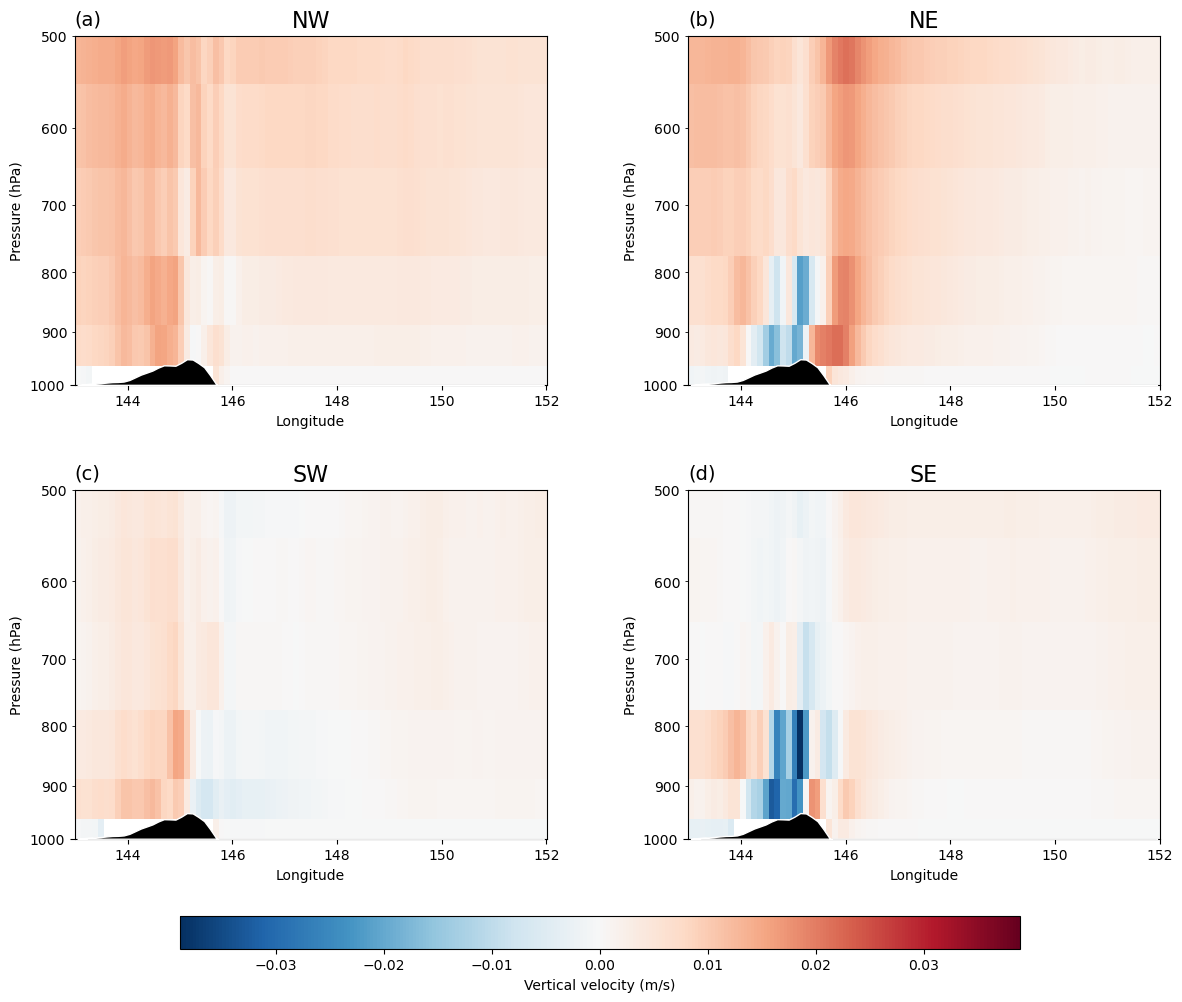

In [85]:
import string
# Create figure with 4 subplots + space for colorbar
fig = plt.figure(figsize=(14, 11))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3, bottom=0.15)
axes = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(2)]
labels = list(string.ascii_lowercase)

regime_names = ['NW', 'NE', 'SW', 'SE']
regimes = ['nw', 'ne', 'sw', 'se']

# Get global min/max for consistent colorbar scaling
vmin = min([results[r][var].min().values for r in regimes])
vmax = max([results[r][var].max().values for r in regimes])
abs_max = max(abs(vmin), abs(vmax))
vmin, vmax = -abs_max, abs_max

for idx, (regime, name) in enumerate(zip(regimes, regime_names)):
    ax = axes[idx]
    
    # Plot
    im = results[regime][var].plot(
        ax=ax,
        cmap='RdBu_r',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    
    ax.set_title(f'{name}', fontsize=16,)# fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Pressure (hPa)')

    # Fill between surface (1000 hPa) and the elevation pressure level
    ax.fill_between(
        lon_vals,
        1000,                          # surface
        topo_pvals,                        # top of terrain in pressure coords
        where=np.isfinite(topo_pvals),     # only where land exists
        color='black',#'saddlebrown',
        alpha=1,
        zorder=5,
        ec='white'
    )
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(matplotlib.ticker.ScalarFormatter())
    ax.invert_yaxis()
    ax.set_ylim(1000,500)
    label_start = idx 
    ax.text(0.00, 1.02, f'({labels[label_start]})',
                transform=ax.transAxes, fontsize=14, va='bottom', ha='left')

# Add colorbar below plots
# cax = fig.add_axes([0.2, 0.05, 0.6, 0.03])
# fig.colorbar(im, cax=cax, orientation='horizontal', label=cbar_label)
cax = fig.add_axes([0.2, 0.05, 0.6, 0.03])
norm = matplotlib.colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='RdBu_r'),
             cax=cax, orientation='horizontal', label=cbar_label)

plt.savefig(f'/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/theta-e_extras/{var}_regime_cairns_1979-2024topobarra.png', dpi=300, bbox_inches='tight')
plt.show()